In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [5]:
file_path = "./Diabates_Dataset.csv"

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")


100%|██████████| 8.91k/8.91k [00:00<?, ?B/s]

Extracting files...


In [6]:
import os

print(os.listdir(path))

['diabetes.csv']


In [117]:
diabates_dataset = os.path.join(path, "diabetes.csv")

df = pd.read_csv(diabates_dataset)


print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]
(768, 9)


In [118]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [119]:
df.shape

(768, 9)

In [120]:
df['Outcome']

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [121]:
y=df['Outcome']

In [123]:
x = df[['Glucose', 'BloodPressure', 'BMI', 'Age']]
y = df['Outcome']

In [124]:
x

,Glucose,BloodPressure,BMI,Age
0,148,72,33.6,50
1,85,66,26.6,31
2,183,64,23.3,32
3,89,66,28.1,21
4,137,40,43.1,33
...,...,...,...,...
763,101,76,32.9,63
764,122,70,36.8,27
765,121,72,26.2,30
766,126,60,30.1,47


In [125]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [126]:
x.shape

(768, 4)

In [127]:
y.shape

(768,)

In [128]:
print(np.sum(y==1))

268


In [129]:
print(np.sum(y==0))

500


In [130]:
type(y)

pandas.Series

In [131]:
y.columns=['Label']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [132]:
y.columns

['Label']

In [133]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [134]:
np.sum(y_train==1)

np.int64(187)

In [135]:
np.sum(y_train==0)

np.int64(350)

In [136]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy={0:500, 1:500})
x_train, y_train = smote.fit_resample(x_train, y_train)

print(x_train.shape)

(1000, 4)


In [137]:
y_train.shape

(1000,)

In [138]:
np.sum(y_train==1)

np.int64(500)

In [139]:
np.sum(y_train==0)

np.int64(500)

In [140]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=2,
    reg_alpha=1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [141]:
print("Train accuracy:", model.score(x_train, y_train))
print("Test accuracy:", model.score(x_test, y_test))

Train accuracy: 0.82
Test accuracy: 0.7792207792207793


In [142]:
pred=model.predict(x_test)

In [143]:
y_prob = model.predict_proba(x_test)[:,1]

y_pred_new = (y_prob > 0.4).astype(int)

In [144]:
accuracy=accuracy_score(y_test,pred)
accuracy

0.7792207792207793

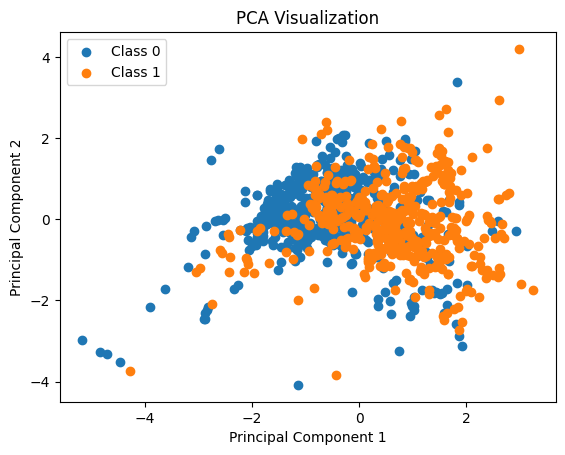

In [145]:
from sklearn.decomposition import PCA

# Scale data (ONLY for PCA)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)

# Apply PCA (2D)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# Plot
plt.figure()
for label in set(y_train):
    plt.scatter(
        x_pca[y_train == label, 0],
        x_pca[y_train == label, 1],
        label=f"Class {label}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.legend()
plt.show()

In [147]:
test_cases = [
    [90, 70, 22.0, 25],    # Healthy
    [130, 85, 28.0, 35],   # Borderline
    [210, 90, 32.0, 45],   # High glucose
    [160, 95, 36.0, 55],   # Obese + age
    [110, 100, 38.0, 60]   # Hidden risk
]
test_cases=np.array(test_cases)
print(model.predict(test_cases))

[0 0 1 1 1]


In [148]:
for test in test_cases:
    prob = model.predict_proba(test.reshape(1, -1))[0][1]
    print(prob)

0.061885796
0.4598395
0.9059988
0.87586063
0.6060907


In [149]:
p=model.predict_proba(test_cases)[:,1]
p=pd.DataFrame({'Risk_Probablity':p,'Risk':None})
p

,Risk_Probablity,Risk
0,0.061886,None
1,0.459839,None
2,0.905999,None
3,0.875861,None
4,0.606091,None


In [161]:
def risk_predictor(data):
    probabilities = model.predict_proba(data)[:, 1]

    df = pd.DataFrame({
        'Risk_Probability': probabilities
    })

    df['Risk'] = df['Risk_Probability'].apply(
        lambda x: 'Low' if x <= 0.3 else ('Moderate' if x <= 0.7 else 'High')
    )

    return df

In [162]:
risk_predictor(test_cases)

,Risk_Probability,Risk
0,0.061886,Low
1,0.459839,Moderate
2,0.905999,High
3,0.875861,High
4,0.606091,Moderate


In [163]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       150
           1       0.65      0.80      0.72        81

    accuracy                           0.78       231
   macro avg       0.76      0.78      0.77       231
weighted avg       0.80      0.78      0.78       231



In [164]:
import pdfplumber

def extract_text_from_pdf(file_path):
    text = ""
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

In [165]:
import re

def extract_features(text):
    features = {}

    # Glucose
    g = re.search(r'glucose[:\s]+(\d+)', text, re.I)
    if g:
        features['Glucose'] = int(g.group(1))

    # Blood Pressure
    bp = re.search(r'(\d{2,3})/(\d{2,3})', text)
    if bp:
        features['BloodPressure'] = int(bp.group(1))

    # BMI
    bmi = re.search(r'bmi[:\s]+([\d.]+)', text, re.I)
    if bmi:
        features['BMI'] = float(bmi.group(1))

    # Age
    age = re.search(r'age[:\s]+(\d+)', text, re.I)
    if age:
        features['Age'] = int(age.group(1))

    return features

In [166]:
def prepare_input(features):
    return [[
        features.get('Glucose'),
        features.get('BloodPressure'),
        features.get('BMI'),
        features.get('Age')
    ]]

In [198]:
def generate_reason(features):
    reasons = []

    # Glucose
    glucose = features.get('Glucose', 0)
    if glucose > 180:
        reasons.append("High glucose level")
    elif glucose >= 126:
        reasons.append("Elevated glucose level (prediabetic range)")
    elif glucose >= 70:
        reasons.append("Glucose level within normal range")

    # Blood Pressure (systolic)
    bp = features.get('BloodPressure', 0)
    if bp > 140:
        reasons.append("High blood pressure (hypertension)")
    elif bp >= 130:
        reasons.append("Slightly elevated blood pressure")
    elif bp >= 90:
        reasons.append("Blood pressure within normal range")

    # BMI
    bmi = features.get('BMI', 0)
    if bmi > 30:
        reasons.append("High BMI (obesity)")
    elif bmi >= 25:
        reasons.append("BMI indicates overweight condition")
    elif bmi >= 18.5:
        reasons.append("BMI within normal range")

    # Age
    age = features.get('Age', 0)
    if age > 45:
        reasons.append("Age-related risk factor present")
    elif age >= 30:
        reasons.append("Moderate age-related risk")
    else:
        reasons.append("Low age-related risk")

    return reasons

In [199]:
def analyze_pdf(file_path):

    # Step 1: Extract text
    text = extract_text_from_pdf(file_path)

    # Step 2: Extract features
    features = extract_features(text)

    # Step 3: Prepare input
    input_data = prepare_input(features)

    # Step 4: Predict
    result_df = risk_predictor(input_data)

    # Step 5: Generate reasons
    reasons = generate_reason(features)

    return {
        "Extracted_Text": text[:300],  # preview
        "Features": features,
        "Prediction": result_df.to_dict(orient='records'),
        "Reasons": reasons
    }

In [200]:
result=analyze_pdf('sample_medical_report.pdf')

In [201]:
def format_output(result):

    pred = result['Prediction'][0]
    risk = pred['Risk']
    prob = pred['Risk_Probability'] * 100

    reasons = result['Reasons']

    # Advice
    if risk == "High":
        advice = "Consult a doctor immediately. Lifestyle changes are recommended."
    elif risk == "Moderate":
        advice = "Monitor your health and consider medical consultation."
    else:
        advice = "Your health parameters are within normal range."

    output = f"""
Risk Level: {risk.upper()}
Confidence: {prob:.2f}%
    """
    for r in reasons:
        output += f"\n- {r}"

    output += f"""
    
Advice: {advice}
    """

    return output

In [202]:
print(format_output(result))


Risk Level: HIGH
Confidence: 87.99%
    
- High glucose level
- High blood pressure (hypertension)
- High BMI (obesity)
- Moderate age-related risk

Advice: Consult a doctor immediately. Lifestyle changes are recommended.
    


In [203]:
report2=analyze_pdf('sample_medical_report_2.pdf')

In [204]:
print(format_output(report2))


Risk Level: HIGH
Confidence: 80.53%
    
- Elevated glucose level (prediabetic range)
- Slightly elevated blood pressure
- Moderate age-related risk

Advice: Consult a doctor immediately. Lifestyle changes are recommended.
    
